### Histórico TRM

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
from market_col.dir_set import project_root_nb
from market_col.figures import static_plot
from market_col.plotly import plotly_oneplot

In [2]:
PROJECT_DIR = project_root_nb()

In [3]:
url = "https://www.datos.gov.co/resource/32sa-8pi3.json"
newTRM = pd.read_json(url)

In [4]:
newTRM["vigenciadesde"] = pd.to_datetime(newTRM["vigenciadesde"])
newTRM["vigenciahasta"] = pd.to_datetime(newTRM["vigenciahasta"])
newTRM = newTRM[["vigenciadesde", "vigenciahasta", "valor"]]

In [5]:
# Crear una lista de fechas para cada fila
newTRM["fecha"] = newTRM.apply(
    lambda x: pd.date_range(x["vigenciadesde"], x["vigenciahasta"], freq="D"),
    axis=1
)

# Expandir las listas
newTRM = newTRM.explode("fecha")

# Conservar únicamente lo necesario
newTRM = (
    newTRM[["fecha", "valor"]]
    .reset_index(drop=True)
)

print(newTRM.head())

       fecha    valor
0 2026-08-01  3144.14
1 2026-08-02  3144.14
2 2026-08-03  3144.14
3 2026-07-31  3132.42
4 2026-07-30  3206.18


In [6]:
newTRM = newTRM.sort_values(by='fecha', ascending=True).reset_index(drop=True)

In [7]:
oldTRM = pd.read_csv(f"{PROJECT_DIR}/Data/TRM/TRM.csv", parse_dates=["fecha"])

In [8]:
fullTRM = pd.concat([oldTRM, newTRM]).drop_duplicates(subset='fecha', keep='last').reset_index(drop=True)

In [9]:
fullTRM.to_csv(f"{PROJECT_DIR}/Data/TRM/newTRM.csv", index=False)
fullTRM['fecha'] = pd.to_datetime(fullTRM['fecha'])

In [10]:
fullTRM

,fecha,valor
0,2022-04-30,3966.27
1,2022-05-01,3966.27
2,2022-05-02,3966.27
3,2022-05-03,4004.07
4,2022-05-04,4016.34
...,...,...
1552,2026-07-30,3206.18
1553,2026-07-31,3132.42
1554,2026-08-01,3144.14
1555,2026-08-02,3144.14


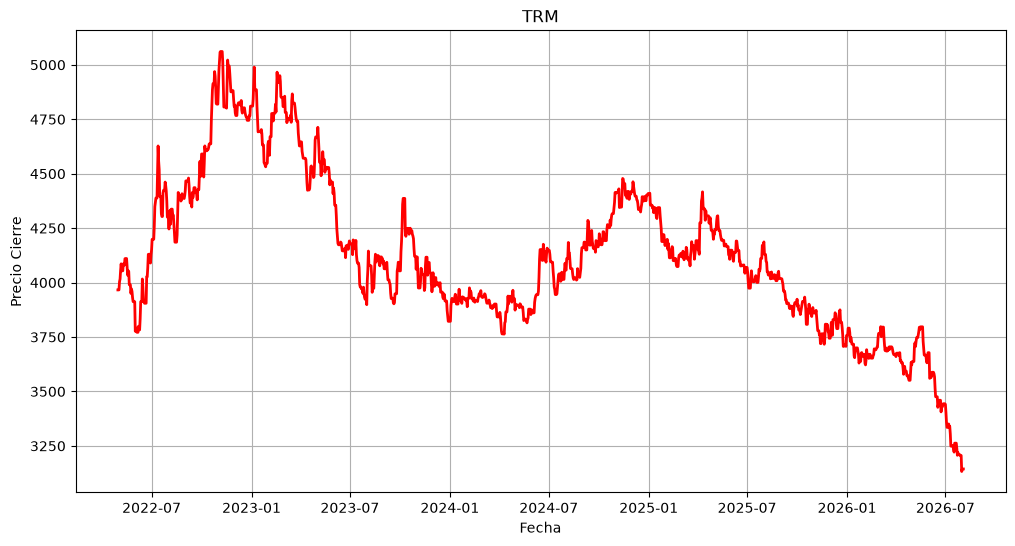

In [11]:
titulo = "TRM"
plt.figure(figsize=(12,6))
plt.plot(fullTRM["fecha"], fullTRM["valor"], color = "red", linewidth=2)
plt.title(titulo)
plt.xlabel("Fecha")
plt.ylabel("Precio Cierre")
plt.grid(True)
plt.show()

In [13]:
plotly_oneplot(data = fullTRM, x_col="fecha", y_col="valor", plot_title="TRM")